# Regresión lineal

En este notebook trabajaremos con datos simulados para estudiar:

- cómo se ajusta una regresión lineal
- cómo se evalúa un modelo de regresión
- cómo cambia el ajuste frente a outliers
- cómo funciona Gradient Descent
- cómo Ridge, Lasso y Elastic Net modifican los coeficientes.


Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)



## Instrucciones

Este notebook combina celdas demostrativas con preguntas de análisis.

No basta con ejecutar el código: deben interpretar los resultados, comparar métricas y justificar sus respuestas usando gráficos, coeficientes y residuos.

In [2]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from sklearn import metrics
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict
from sklearn.model_selection import KFold
from sklearn import linear_model # Nuevo modelo desbloqueado

font = {'size'   : 16}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=14) 
matplotlib.rc('ytick', labelsize=14) 
#matplotlib.rcParams.update({'figure.autolayout': False})
matplotlib.rcParams['figure.dpi'] = 300

In [3]:
from sklearn.metrics._scorer import _SCORERS

#### Generamos un dataset de juguete

Primero trabajaremos con datos simulados. La ventaja es que conocemos la relación verdadera:
$$
y_{\rm true} = 3x + 3
$$

Luego agregamos ruido para simular mediciones imperfectas.

In [4]:
np.random.seed(16) #fijar semilla para la reproducibilidad

x = np.arange(100) 

yp = 3*x + 3 + 2*(np.random.poisson(3*x+3,100)-(3*x+3)) 
#genera datos con dispersión, siguiendo una distribución Poissoniana
# con valor esperado = y (modelo lineal), centrado alrededor de cero

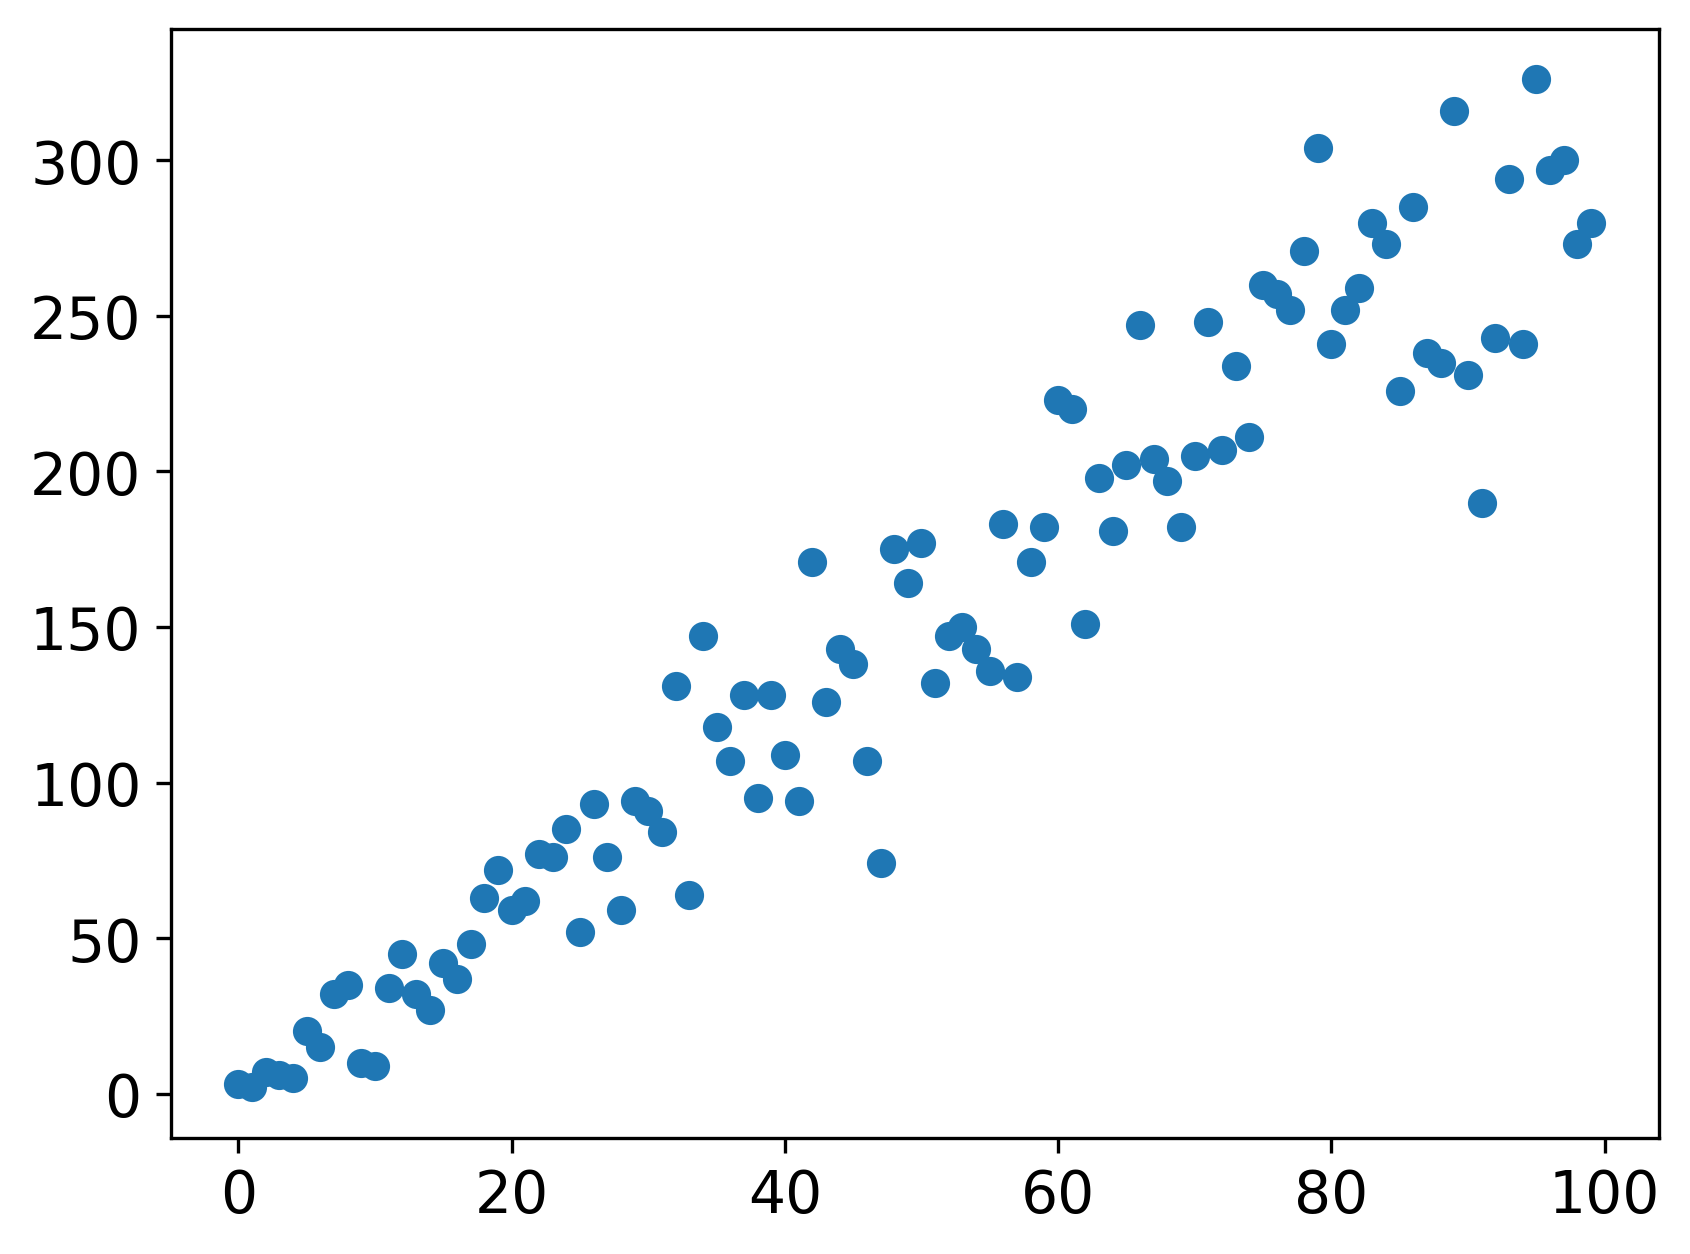

In [5]:
plt.scatter(x, yp);

### Pregunta 

De acuerdo al gráfico anterior:
- ¿Los datos siguen una tendencia aproximadamente lineal?

Si, una linea recta seria una representación adecuada de la tendencia aproximada de los datos

- ¿La dispersión alrededor de la recta parece constante para todos los valores de \(x\)?

No, la dispersión no se muestra constante alrededor de la recta
- ¿Qué podría implicar esto al mirar residuos más adelante?

que habra datos cuyo residuo pesara mas al ser mas grande

In [6]:
model = linear_model.LinearRegression()

#### Ajuste con regresión lineal

Ajustaremos un modelo de la forma:

$$
\hat{y} = \beta_0 + \beta_1 x
$$

En `sklearn`, cuando tenemos una sola feature, necesitamos escribir `x` como una matriz de forma `(n_samples, 1)`. Por eso usamos:

```python
x.reshape(-1, 1)

In [7]:
model.fit(x.reshape(-1, 1), yp)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
slope = model.coef_[0]
intercept = model.intercept_

print(f"Intercepto beta_0 = {intercept:.3f}")
print(f"Pendiente beta_1 = {slope:.3f}")

Intercepto beta_0 = -0.126
Pendiente beta_1 = 3.025


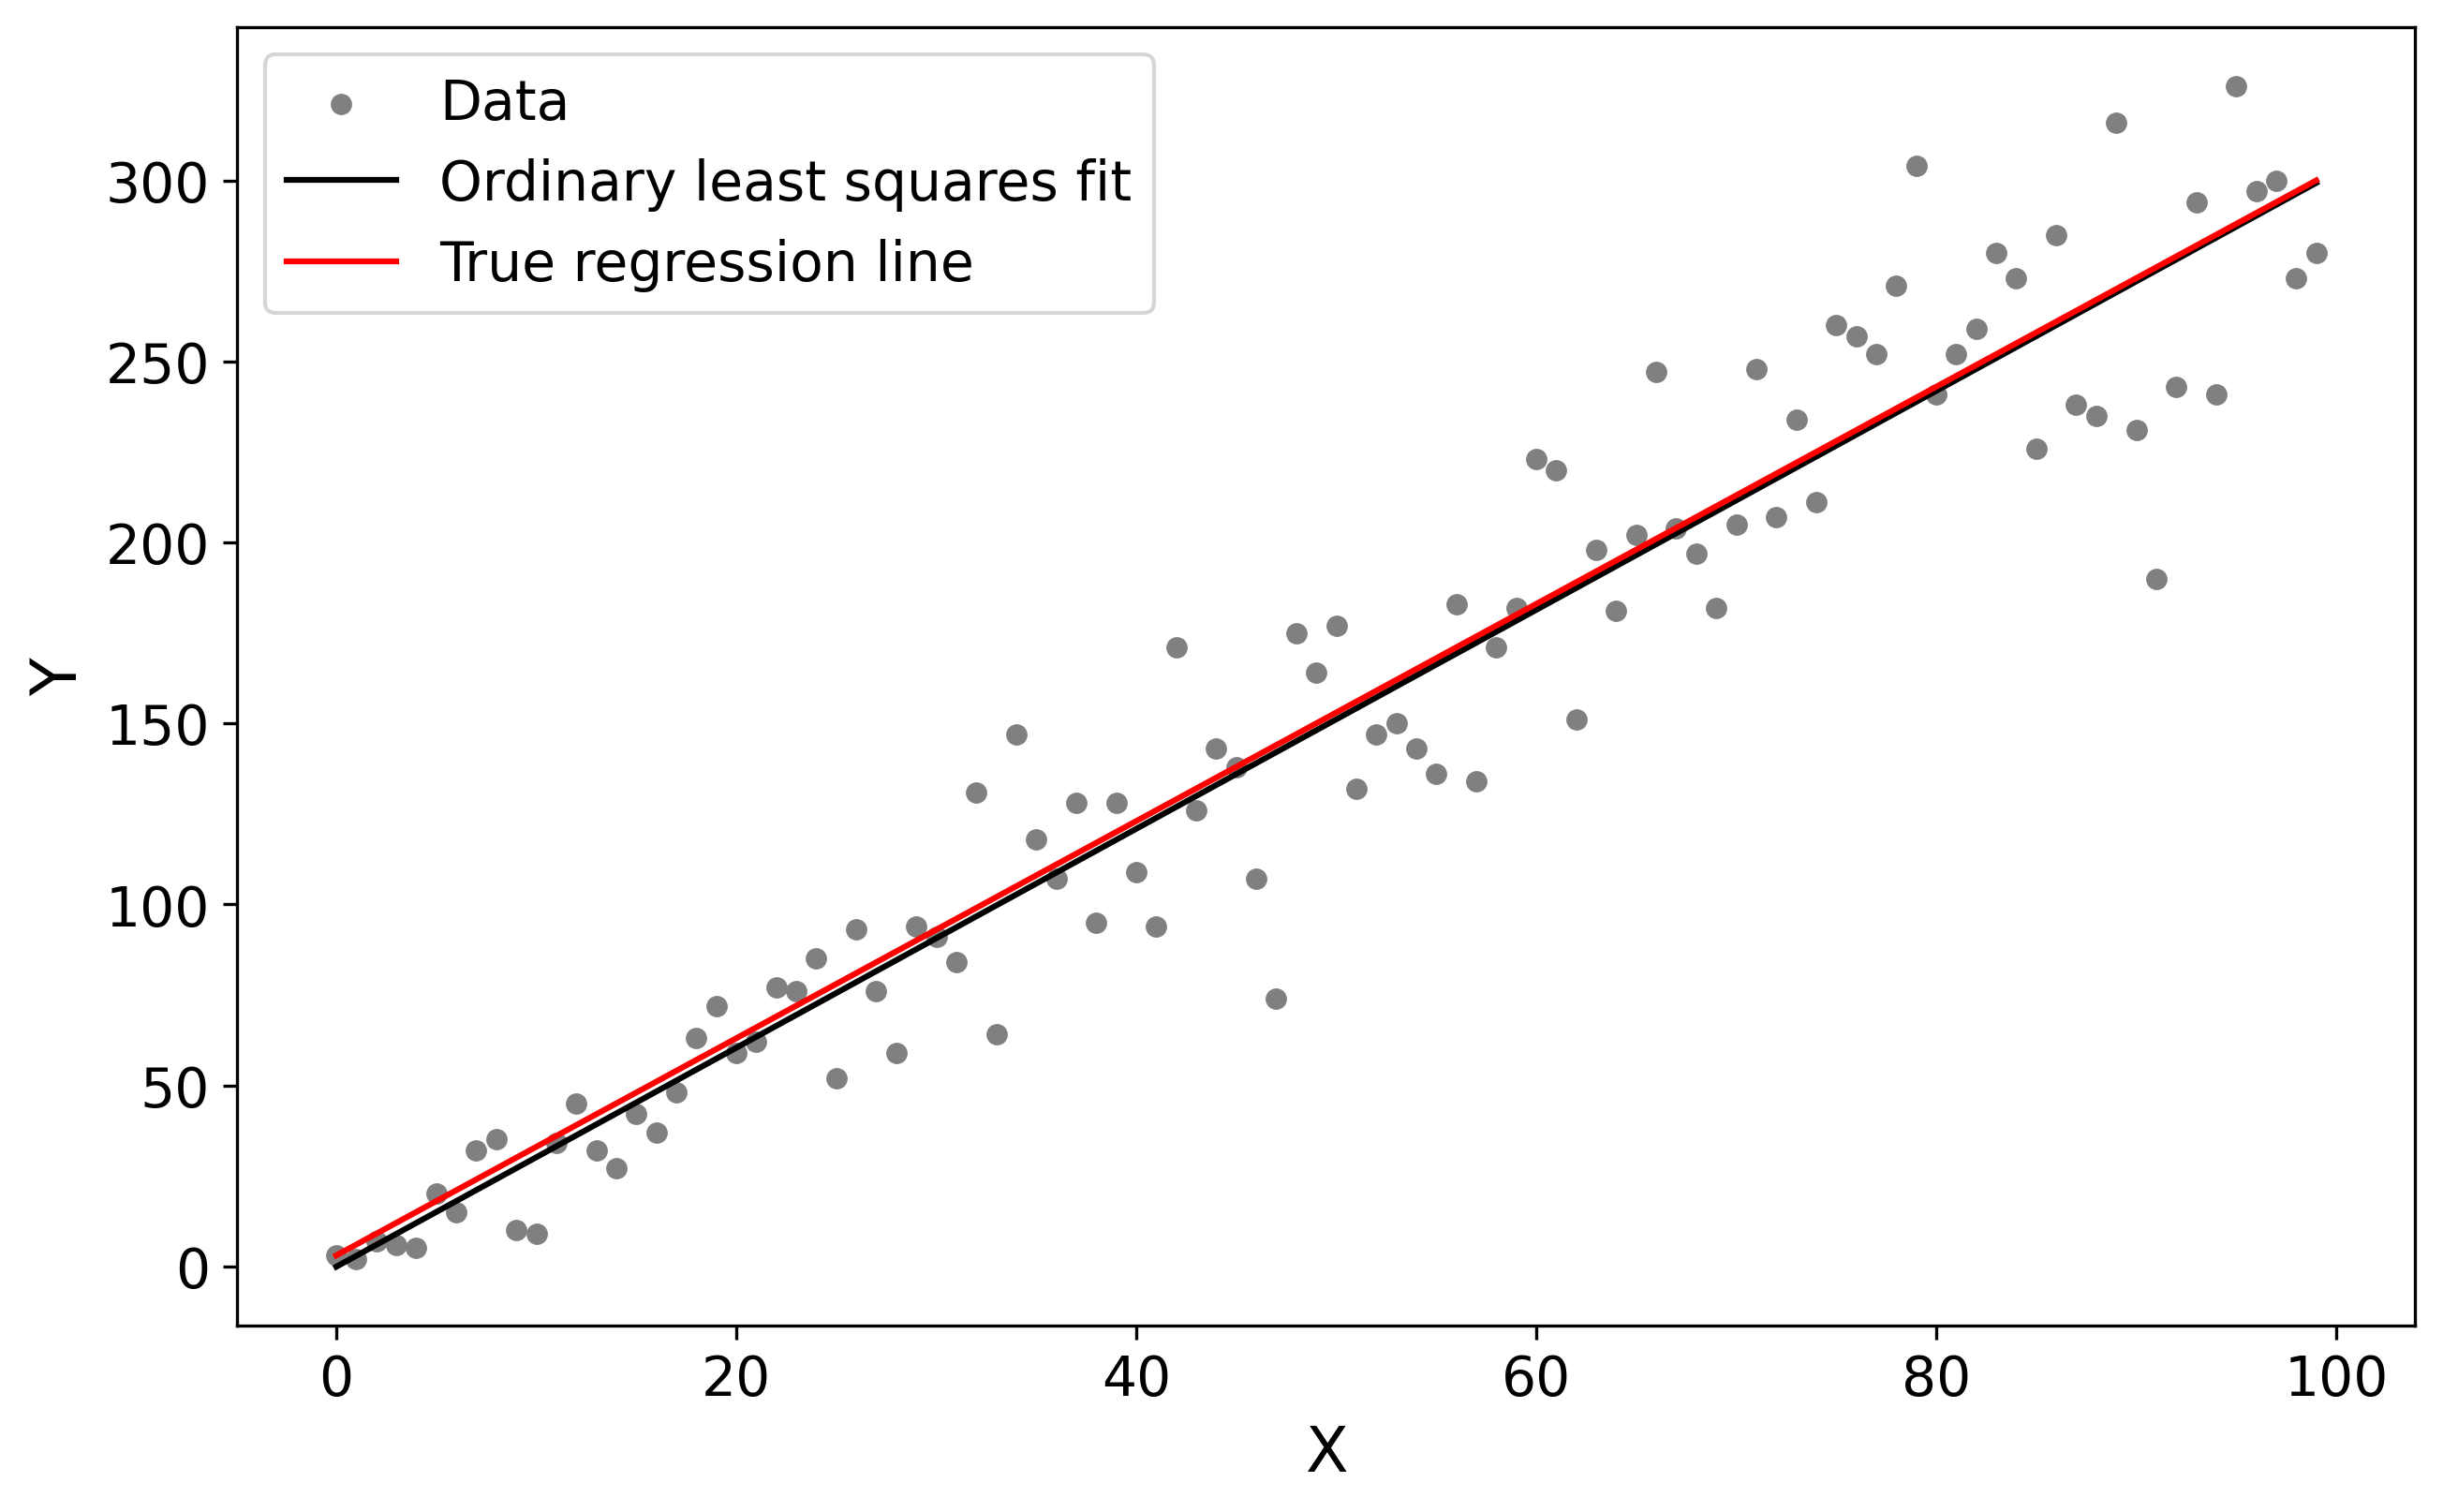

In [9]:
plt.figure(figsize = (10,6))
plt.scatter(x,yp, s = 20, c = 'gray', label = 'Data')
plt.plot(x, slope*x + intercept, c ='k', label = 'Ordinary least squares fit')
plt.plot(x, 3*x + 3, c = 'r', label = 'True regression line')
plt.legend(fontsize = 14)
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

### Pregunta

Compara los coeficientes ajustados con los valores verdaderos $\beta_0=3$ y $\beta_1=3$
-  ¿Son exactamente iguales? ¿Por qué?

No, por que no se minimizaron los cuadrados por ende no necesariamente los cuadrados encontrados eran los mas optimos para la muestra
-  ¿Qué representa físicamente/matemáticamente la pendiente en este modelo?

Es el ritmo de con el que la variable x cambia con respecto a y

#### Solución analítica de mínimos cuadrados

Para regresión lineal simple, la pendiente que minimiza el MSE puede escribirse como:

$$
\beta_1 =
\frac{\sum_i (x_i-\bar{x})(y_i-\bar{y})}
{\sum_i (x_i-\bar{x})^2}
$$

y luego:

$$
\beta_0 = \bar{y} - \beta_1\bar{x}
$$

**Implemente en el código para calcular a partir de la solución analítica los coeficientes y compare**

In [10]:
# Cálculo analítico de los coeficientes de la regresión lineal
beta0= yp.mean() - slope*x.mean()
beta1= np.sum((x - x.mean())*(yp - yp.mean())) / np.sum((x - x.mean())**2)

print(f"Beta_0 analítico = {beta0:.3f}")
print(f"Beta_1 analítico = {beta1:.3f}")

Beta_0 analítico = -0.126
Beta_1 analítico = 3.025


#### Evaluación del modelo: validación cruzada y métricas

Ahora aplicamos una idea que ya usamos en clasificación: validar el modelo en distintos subconjuntos de datos.

Por defecto, `LinearRegression.score()` devuelve \(R^2\), no accuracy.

Podemos ver todos los scorers implementados en sklearn

In [11]:
from sklearn.metrics import get_scorer_names
print(get_scorer_names())

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'd2_absolute_error_score', 'd2_brier_score', 'd2_log_loss_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_max_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_m

#### Implemente una validación cruzada con Kfold

y encuentre los resultados para las métricas R^2, 'neg_mean_absolute_error'  (MAE) y 'neg_mean_squared_error' (MSE)

Para los estimadores de la performance del modelo del tipo "error" siempre queremos que sean pequeños (menor error, mejor modelo). Pero en sklearn, reciben un signo negativo, como neg_mean_squared_error, para mantener la consistencia de "alto puntaje=mejor" de los scorers

In [12]:
# Evaluación del modelo con validación cruzada
cv = KFold(n_splits=5, shuffle=True, random_state=16)
scores = cross_validate(model, x.reshape(-1, 1), yp, cv=cv, scoring=['neg_mean_squared_error', 'r2'])
print(f"Mean squared error (MSE) promedio: {-scores['test_neg_mean_squared_error'].mean():.3f}")
print(f"R^2 promedio: {scores['test_r2'].mean():.3f}")

Mean squared error (MSE) promedio: 640.938
R^2 promedio: 0.918


In [13]:
scores_r2 = cross_validate(model, x.reshape(-1, 1), yp, cv=cv, scoring='r2', return_train_score=True)
print(f"R2 test : {scores_r2['test_score'].mean():.3f} ± {scores_r2['test_score'].std():.3f}")
print(f"R2 train: {scores_r2['train_score'].mean():.3f} ± {scores_r2['train_score'].std():.3f}")

R2 test : 0.918 ± 0.052
R2 train: 0.925 ± 0.011


In [14]:
scores_mse = cross_validate(model, x.reshape(-1, 1), yp, cv=cv, scoring='neg_mean_squared_error')

scores_mae = cross_validate(model, x.reshape(-1, 1), yp, cv=cv, scoring='neg_mean_absolute_error')

print(f"MSE test: {-scores_mse['test_score'].mean():.3f}")
print(f"MAE test: {-scores_mae['test_score'].mean():.3f}")

MSE test: 640.938
MAE test: 19.160


**Haga un gráfico de los residuos $r_i=y_i-\hat{y}_i$**

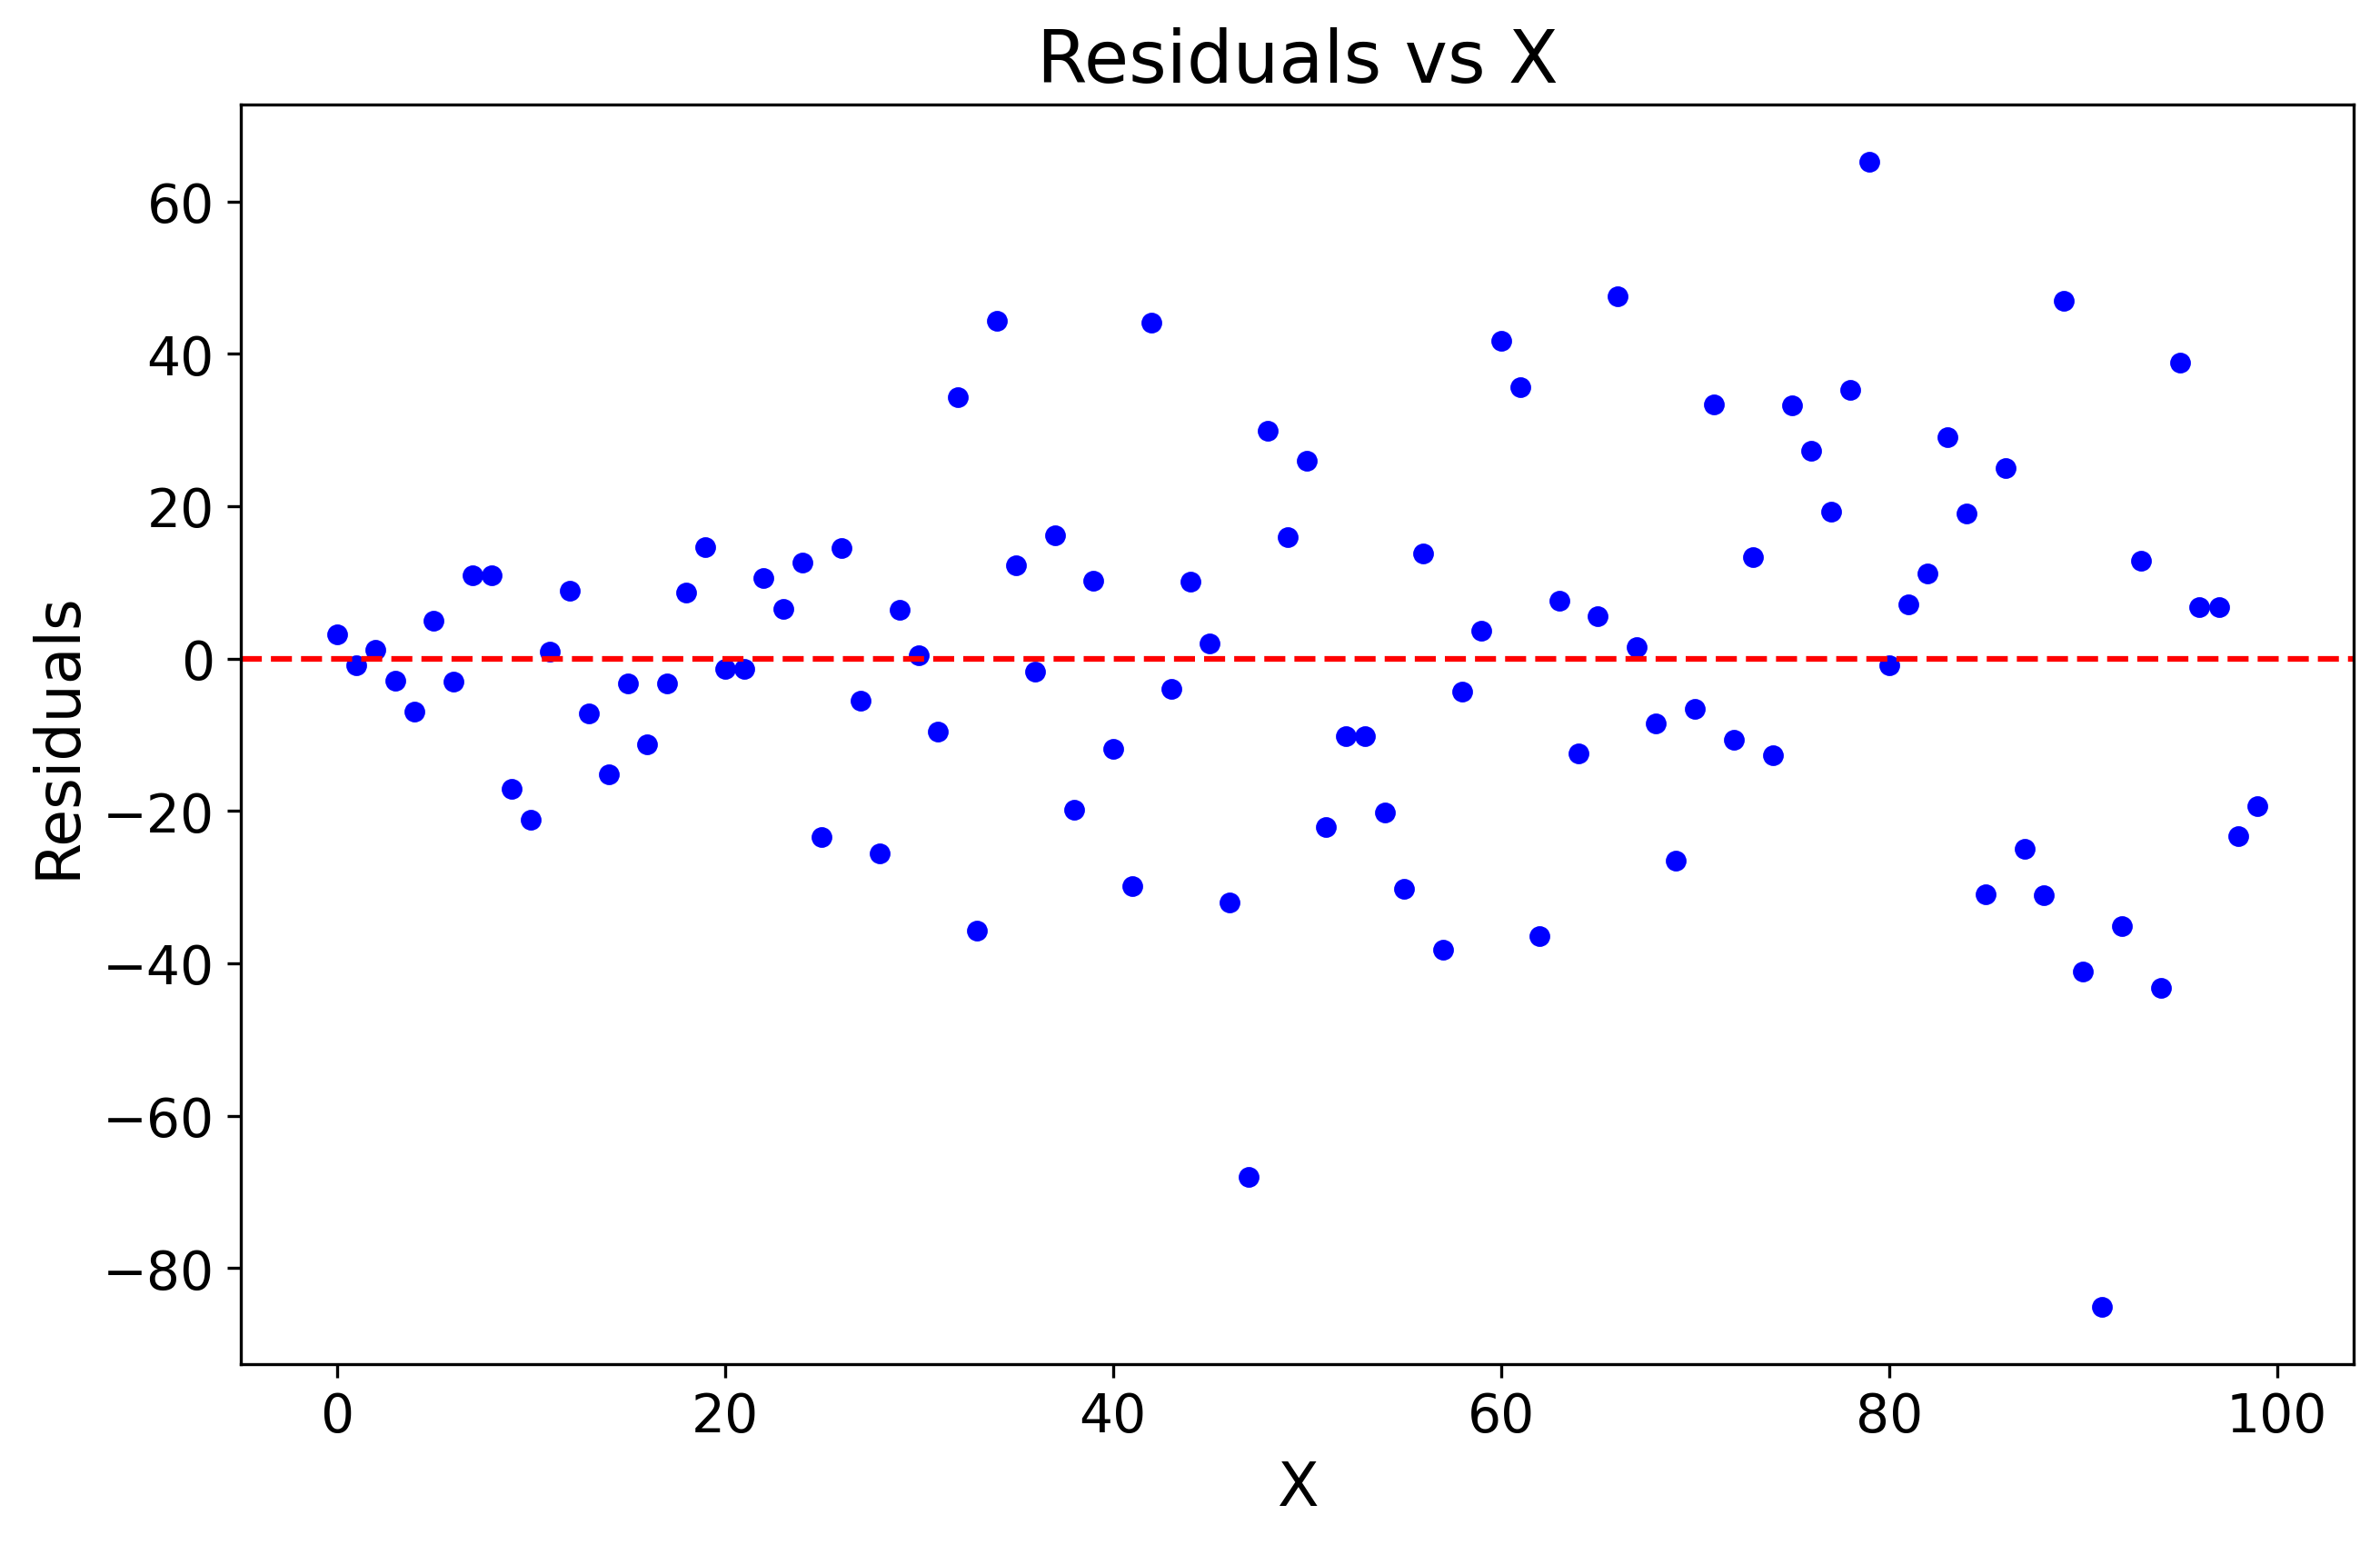

In [15]:
# Graficar los residuos
yp_pred = model.predict(x.reshape(-1, 1))
residuals = yp - yp_pred
plt.figure(figsize=(10,6))
plt.scatter(x, residuals, s=20, c='blue')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('X')
plt.ylabel('Residuals')
plt.title('Residuals vs X')
plt.show()

#### Pregunta 
-  ¿Los residuos parecen distribuidos aleatoriamente alrededor de cero?

No
-  ¿La dispersión de los residuos cambia con $x$?

Si, los residuos con x menores son mas cercanos a cero y conforme los x crecen tambien lo hace la dispersión de los residuos
-  ¿Qué nos dice esto sobre el modelo y/o sobre cómo fueron generados los datos?



### ¿Qué ocurre si agregamos outliers?

In [ ]:
np.random.seed(12) # fijada la semilla
out = np.random.choice(100,15) #seleccionamos 15 índices de outliers
yp_wo = np.copy(yp)
np.random.seed(12) #fijada 
yp_wo[out] = yp_wo[out] + 5*np.random.rand(15)*yp[out]

model.fit(x.reshape(-1, 1), yp_wo)
slope_o = model.coef_[0]
intercept_o = model.intercept_

beta0_o= yp_wo.mean() - slope_o*x.mean()
beta1_o= np.sum((x - x.mean())*(yp_wo - yp_wo.mean())) / np.sum((x - x.mean())**2)

print(f"Beta_0 analítico = {beta0_o:.3f}")
print(f"Beta_1 analítico = {beta1_o:.3f}")


Beta_0 analítico = 1.548
Beta_1 analítico = 3.978


In [43]:
# Error absoluto medio (MAE) con outliers
scores_mae_o = cross_validate(model, x.reshape(-1, 1), yp_wo, cv=cv, scoring='neg_mean_absolute_error')

# Error cuadrático medio (MSE) con outliers
scores_mse_o = cross_validate(model, x.reshape(-1, 1), yp_wo, cv=cv, scoring='neg_mean_squared_error')

# Raiz del error cuadrático medio (RMSE) con outliers
scores_rmse_o = cross_validate(model, x.reshape(-1, 1), yp_wo, cv=cv, scoring='neg_root_mean_squared_error')                                                                                          

# Error R^2 con outliers
scores_r2_o = cross_validate(model, x.reshape(-1, 1), yp_wo, cv=cv, scoring='r2', return_train_score=True)

# Error absoluto medio (MAE) sin outliers
scores_mae = cross_validate(model, x.reshape(-1, 1), yp, cv=cv, scoring='neg_mean_absolute_error')

# Error cuadrático medio (MSE) sin outliers
scores_mse = cross_validate(model, x.reshape(-1, 1), yp, cv=cv, scoring='neg_mean_squared_error')

# Raiz del error cuadrático medio (RMSE) sin outliers
scores_rmse = cross_validate(model, x.reshape(-1, 1), yp, cv=cv, scoring='neg_root_mean_squared_error')

# Error R^2 sin outliers
scores_r2 = cross_validate(model, x.reshape(-1, 1), yp, cv=cv, scoring='r2', return_train_score=True)

# Imprimir resultados
print("Resultados sin outliers:")
print(f"MAE: {-scores_mae['test_score'].mean():.3f}")
print(f"MSE: {-scores_mse['test_score'].mean():.3f}")
print(f"RMSE: {-scores_rmse['test_score'].mean():.3f}")
print(f"R^2: {scores_r2['test_score'].mean():.3f}")

print("\nResultados con outliers:")
print(f"MAE: {-scores_mae_o['test_score'].mean():.3f}")
print(f"MSE: {-scores_mse_o['test_score'].mean():.3f}")
print(f"RMSE: {-scores_rmse_o['test_score'].mean():.3f}")
print(f"R^2: {scores_r2_o['test_score'].mean():.3f}")

Resultados sin outliers:
MAE: 19.160
MSE: 640.938
RMSE: 24.562
R^2: 0.918

Resultados con outliers:
MAE: 94.278
MSE: 46905.557
RMSE: 172.889
R^2: 0.191


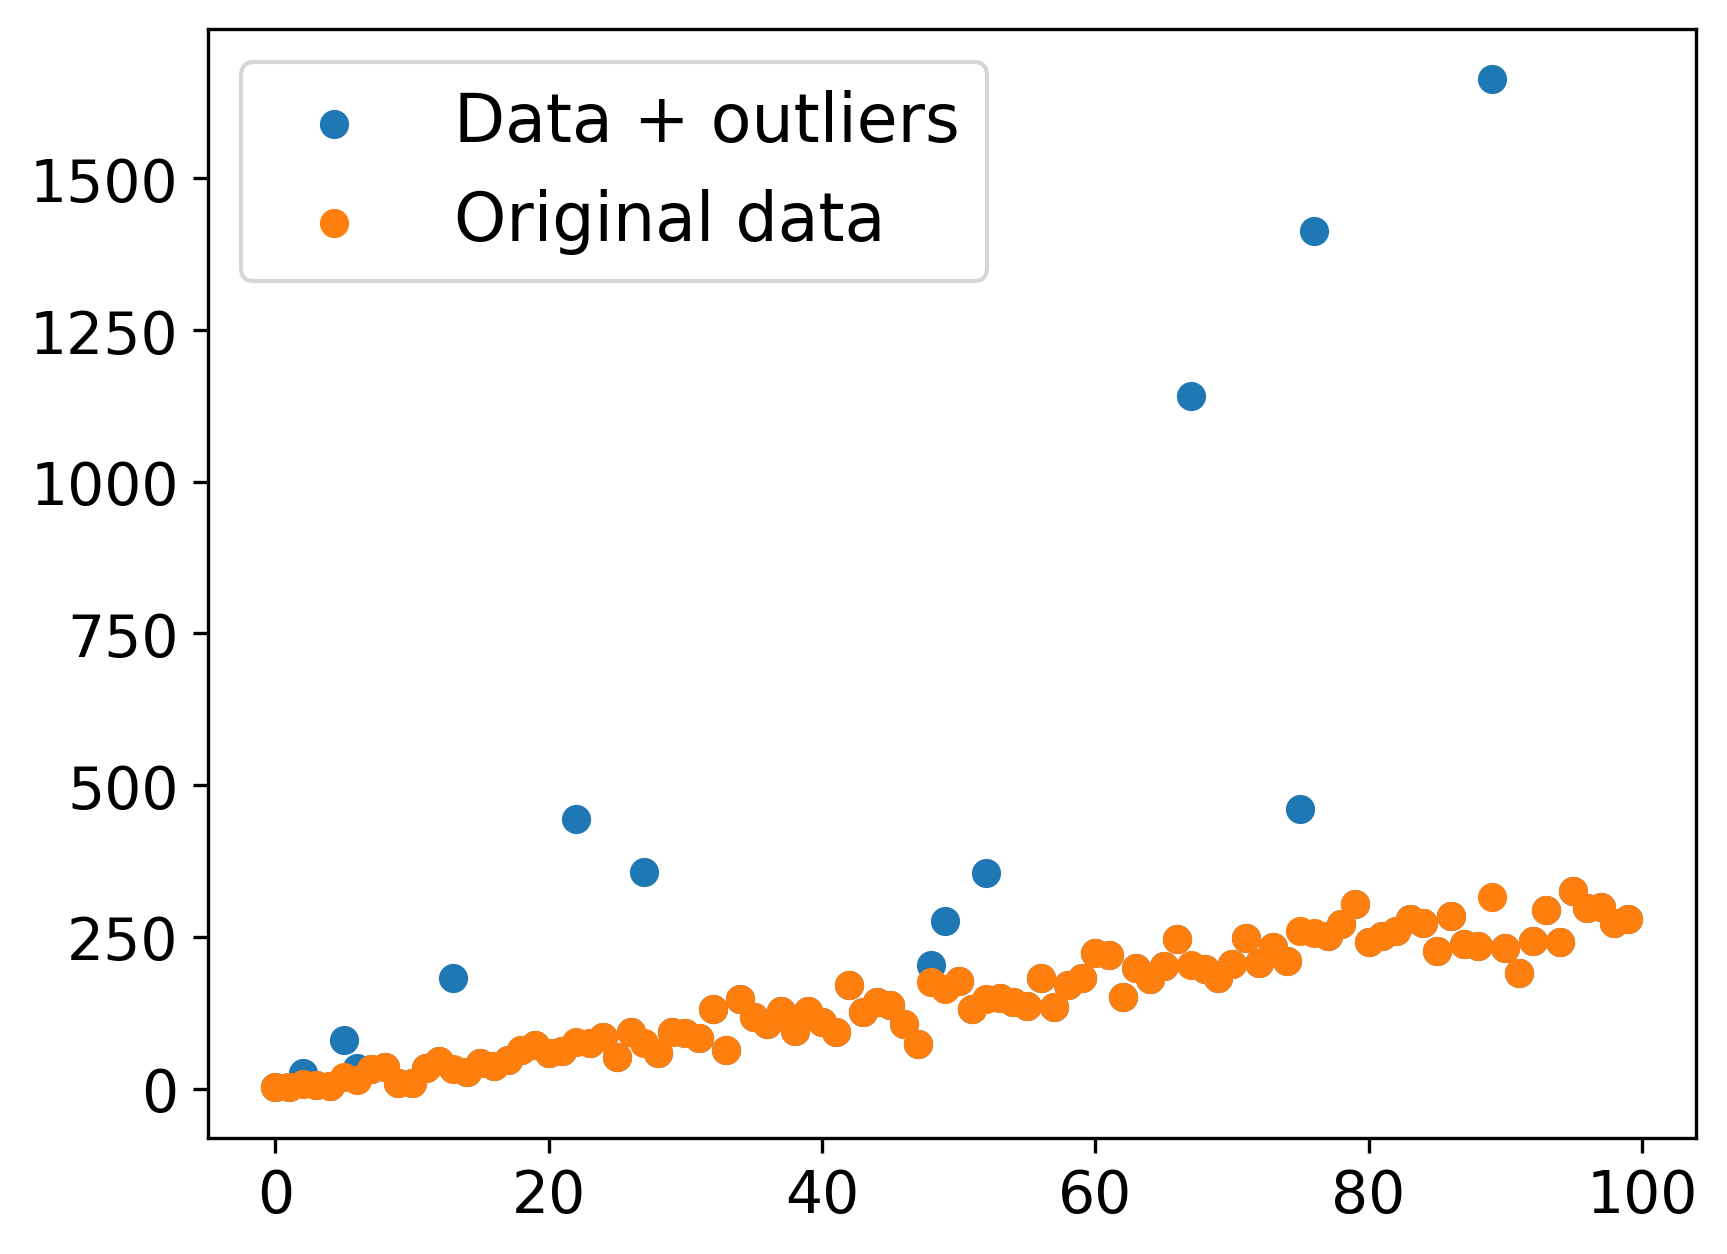

In [17]:
plt.scatter(x,yp_wo, label = 'Data + outliers')
plt.scatter(x,yp, label = 'Original data')
plt.legend();

#### Ajuste el modelo de regresión lineal para los datos con outliers

Responda: 
- Compare visualmente el ajuste antes y después de agregar outliers. ¿La recta cambia mucho? ¿Hacia dónde se mueve?
Dentro del rango de los valores usados se logra apreciar claramente un pendiente diferente pero noes un cambio drastico, la recta aumenta su pendiente mostrando una mayor inclinación interceptando a la antigua recta en los valores menores.
- Compara los coeficientes $\beta_0$ y $\beta_1$ del modelo con y sin outliers.  ¿Cuál cambia más: el intercepto o la pendiente?

modelo con outliers:


beta_0 = 1.548 \
beta_1 = 3.978


modelo sin outliers:

beta_0 = -0.126 \
beta_1 = 3.025

El coeficiente que mas cambia es el intercepto ya que varia su valor en mas de 1.5

- Compara las métricas MAE, MSE, RMSE y $R^2$ antes y después de agregar outliers. ¿Qué métrica se ve más afectada?


El MAE sin outliers es de 19.160 que aumenta casi 5 veces su valor con los outliers llegando a 94.278 \
El MSE sin outliers es de 640.938 que aumenta 2 ordenes de magnitud con los outliers llegando a 46905.557\
El RMSE sin outliers es de 24.562 que aumenta 7 veces con los outliers llegando a 172.889\
El R^2 sin outliers es de 0.918 que disminuyecasi 5 veces con los outliers llegando a 0.191

El MSE es la metrica mas afectada por los outliers 

- ¿Por qué el MSE/RMSE suele ser más sensible a outliers que el MAE?


  Se debe a que en el calculo de ambos eleva los residuos al cuadrado lo que produce que cada variación tenga mayor peso o otras palabras que la metrica sea mas sensible a las variaciones de cada dato.


- ¿Todos los outliers afectan de la misma manera al modelo? Observa si los puntos atípicos están lejos en $y$, lejos en $x$, o en ambos.


- ¿Dirías que el modelo con outliers está aprendiendo la tendencia general de los datos o está siendo “tirado” por algunos puntos extremos? Justifica.
Diria que el modelo esta siendo "tirado" por los outliers en especial lo de valores mayores a 1000 ya que la recta coincide aproximadamente con la recta calculada sin outliers en un comienzo pero a medida que aumenta X se van separando ambas rectas y los outliers con valores mayores a 1000 corresponden a X mayores a 60, sector desde el cual la separación es notable.
- Si este fuera un dataset real, ¿eliminarías los outliers automáticamente? Explica qué revisarías antes de decidir.
No los eliminaria pero los trataria como un fenomeno distinto al de mi interes o caso especiales

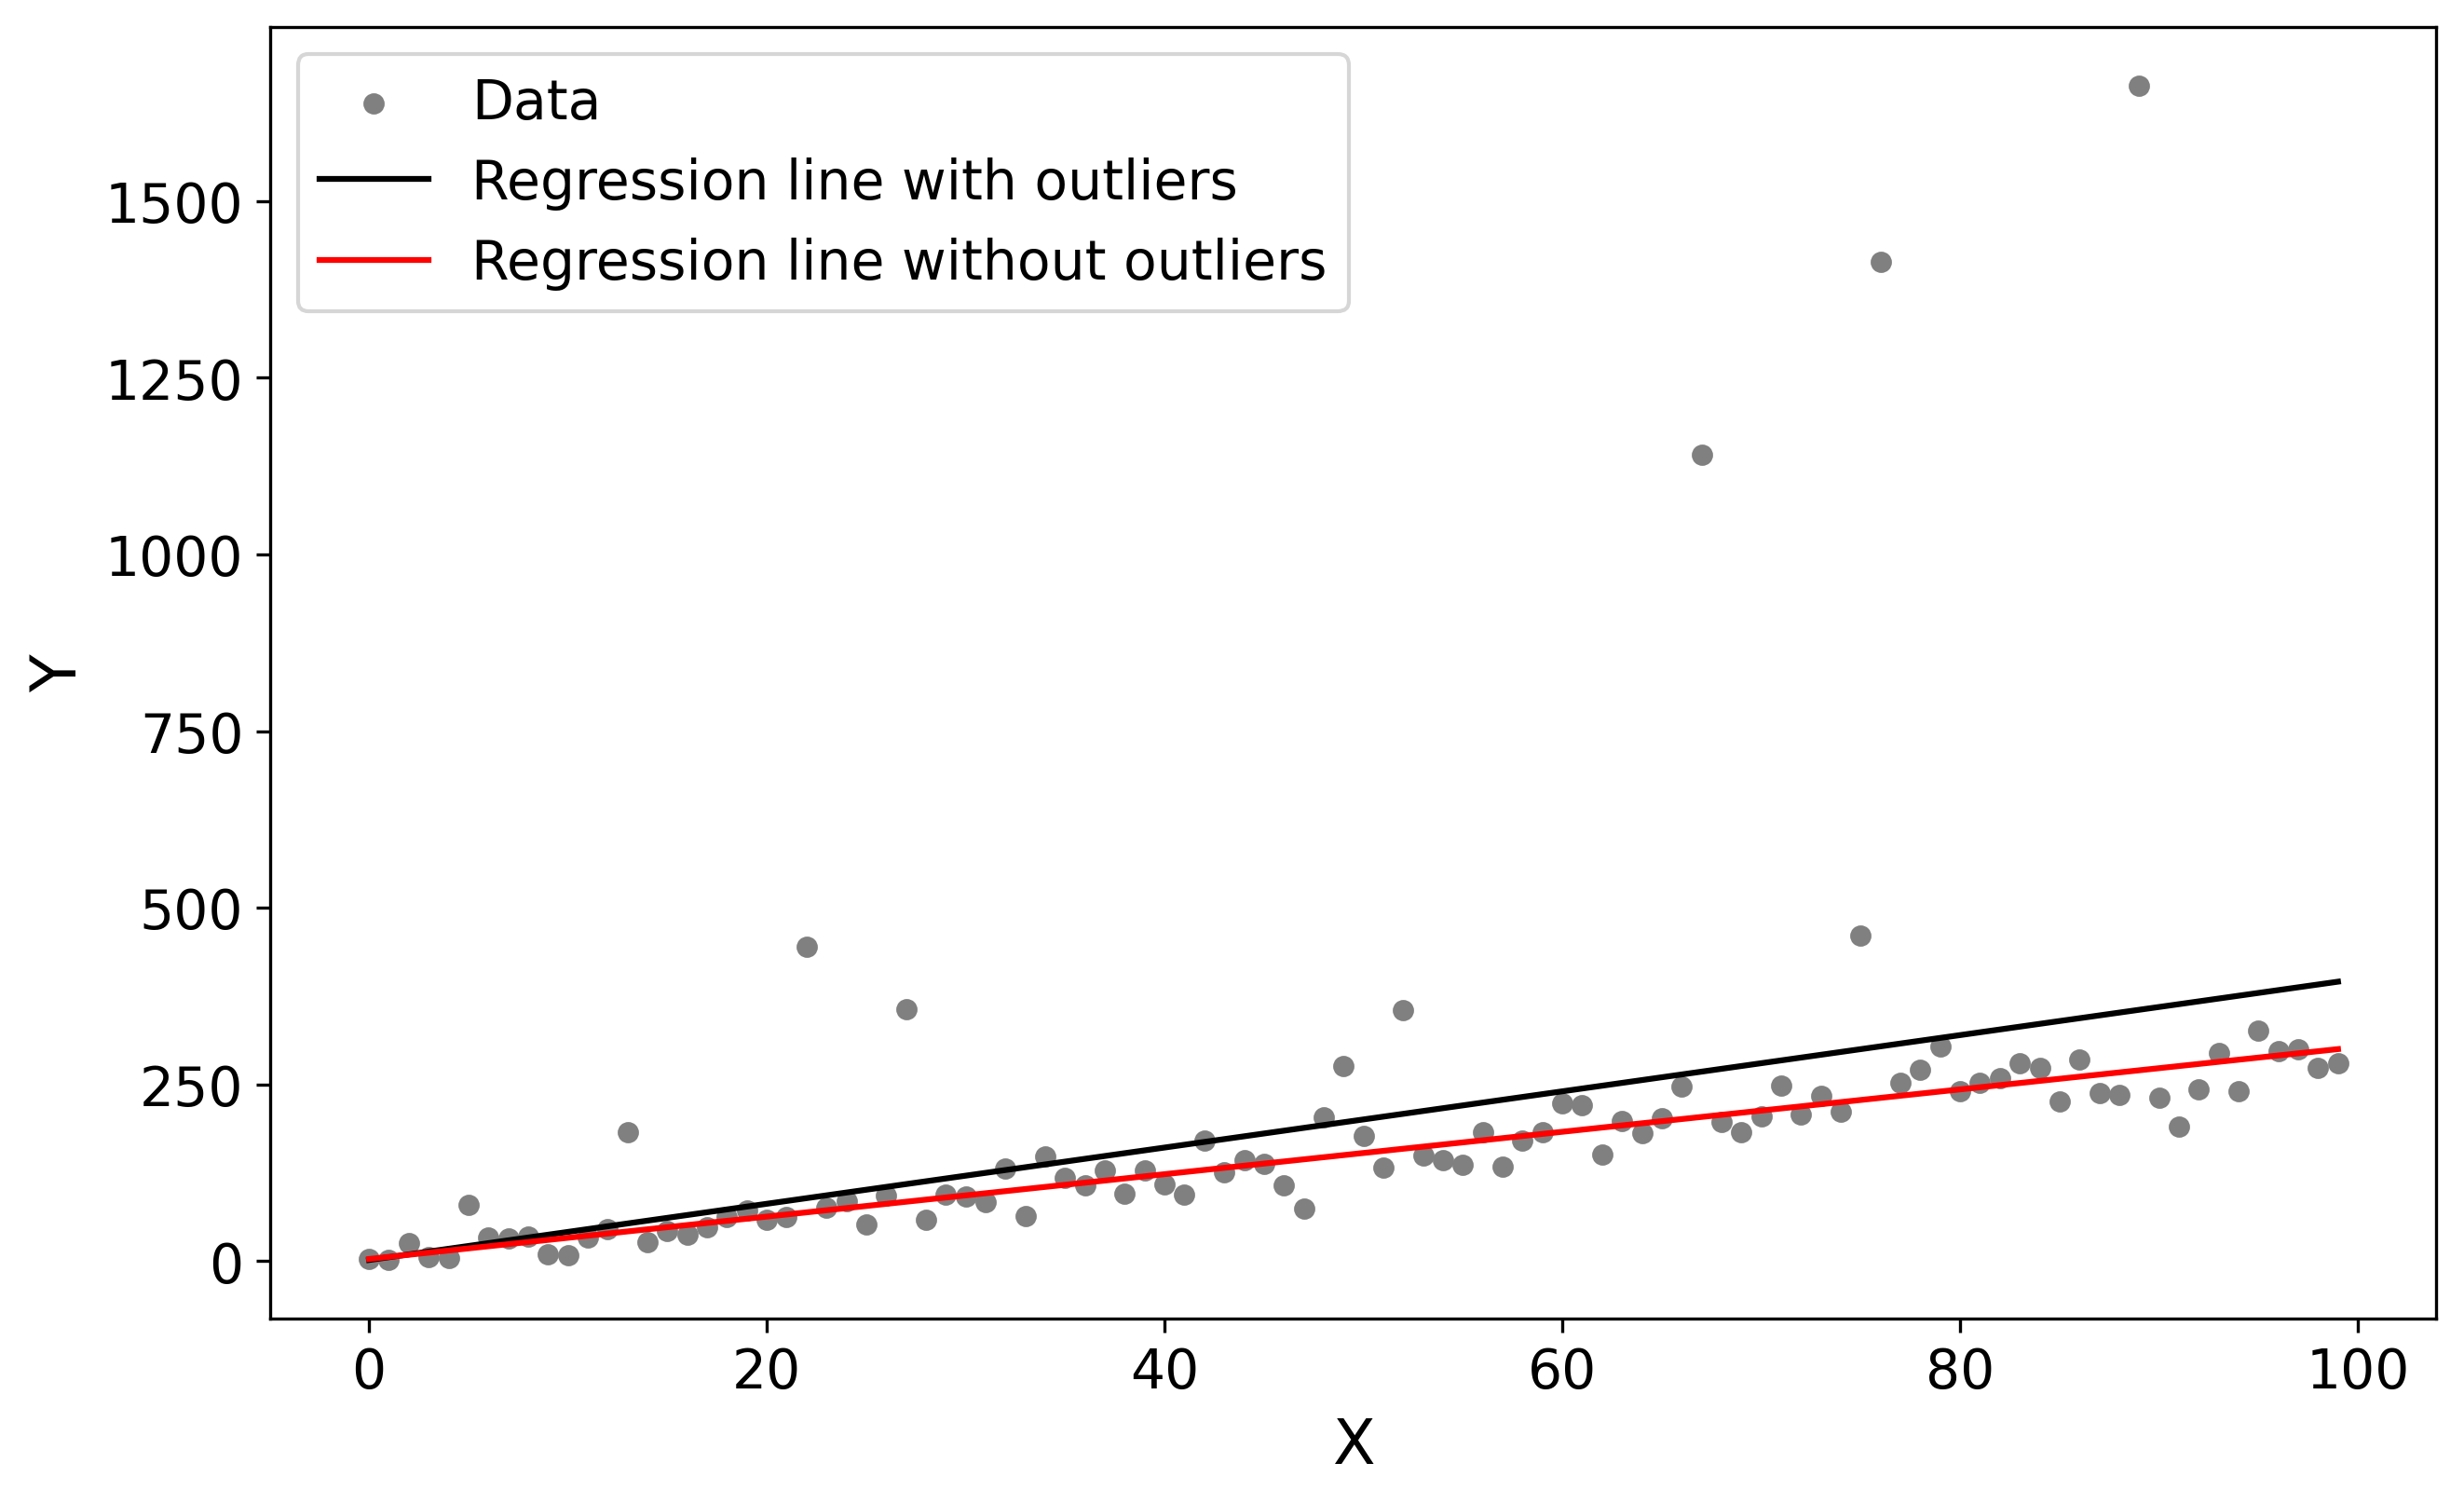

In [ ]:

plt.figure(figsize = (10,6))
plt.scatter(x,yp_wo, s = 20, c = 'gray', label = 'Data')
plt.plot(x, slope_o*x + intercept_o, c ='k', label = 'Regression line with outliers')
plt.plot(x, 3*x + 3, c = 'r', label = 'Regression line without outliers')
plt.legend(fontsize = 14)
plt.xlabel('X')
plt.ylabel('Y')
plt.show()


In [19]:
model_outliers= linear_model.LinearRegression()
model_outliers.fit(x.reshape(-1, 1), yp_wo)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Del resultado del modelo lineal para estos datos con outliers, guarde los coeficientes encontrados en un array llamado `theta_ne`

In [20]:
theta_ne = np.array([["slope obtenida"],["intercept obtenido"]])

Esto es la solución usando el modelo y la **ecuación normal**

### Ahora implementaremos 3 métodos de gradient descent: batch, estocástico y mini-batch

En esta sección ajustamos una regresión lineal usando Gradient Descent en vez de usar directamente `LinearRegression`. Compararemos con los resultados encontrados en la regresión con outliers.




Agregaremos $x_0=1$ a cada instancia, este es el término de bias ($\beta_0$) y se usa para escribir la solución en la forma de multiplicación de matrices 

$y=X\cdot \theta$

donde $\theta$ es el vector de coeficientes que incluye el término $\beta_0$  (término de bias) y $\beta_1, \beta_2, \beta_3,..., \beta_n$

In [21]:
X = np.c_[np.ones((100, 1)), x]  

print(X.shape) #la forma es el número de instancias x número de parámetros


(100, 2)


Podemos calcular la pérdida asociada con la ecuación normal, usando la expresión 

$\text{MSE} = \frac{1}{m}\|X\cdot \theta - y \|^2$

In [22]:
# Calculo de la función de pérdida con outliers
loss_ne = np.mean((x.reshape(-1, 1).dot(model_outliers.coef_.reshape(-1, 1)) + model_outliers.intercept_ - yp_wo.reshape(-1, 1)) ** 2)

### Batch GD

In [23]:
np.random.seed(10) 

eta = 0.0001 #learning step (valor pequeño asegura convergencia, aunque lenta)
n_iterations = 1000 #puede cambiar este valor!!
m = 100 #número de instancias

theta_path_bgd = [] #arreglo para guardar los valores de los parámetros en cada iteración

theta = np.random.randn(2,1) #inicializamos con valores aleatorios

for iteration in range(n_iterations):
    gradients = 2/m * X.T.dot(X.dot(theta) - yp_wo.reshape(-1,1)) #gradiente de la función de pérdida respecto a theta
    theta = theta - eta * gradients #actualiza los valores de theta, en cada cálculo del gradiente, en cada paso
    theta_path_bgd.append(theta) #

theta_path_bgd = np.array(theta_path_bgd) #guardamos esos valores (útil para una visualización)

theta_bgd = theta #resultado final

In [24]:
theta_bgd

array([[1.38909891],
       [3.98081931]])

In [25]:
loss_bgd = np.sum(1/m*(X.dot(theta_bgd) - yp_wo.reshape(-1,1))**2)

In [26]:
loss_bgd

np.float64(43259.08804185896)

In [27]:
(loss_ne-loss_bgd)/loss_ne*100 #diferencia porcentual con la ecuación normal

np.float64(-1.4834194931614274e-05)

###  GD estocástico

In [28]:
np.random.seed(10) #

theta = np.random.randn(2,1)  #inicializa los parámetros

eta = 0.000005 #learning step, valor más pequeño evita saltos muy grandes

n_iterations = 10000 #necesitamos más iteraciones en este caso

theta_path_sgd = []

for epoch in range(n_iterations):
    
        random_index = np.random.randint(m) #índice aleatorio
        
        x_one = X[random_index:random_index+1] #sólo se selecciona una instancia del conjunto de datos (m es la cantidad total)
        
        y_one = yp_wo[random_index:random_index+1] 
        
        gradients = 2 * x_one.T.dot(x_one.dot(theta) - y_one)
        theta = theta - eta * gradients
        theta_path_sgd.append(theta)                 

theta_path_sgd = np.array(theta_path_sgd)

theta_sgd = theta

In [29]:
theta_sgd

array([[1.3552955 ],
       [4.17721319]])

In [30]:
loss_sgd = np.sum(1/m*(X.dot(theta_sgd) - yp_wo.reshape(-1,1))**2)

In [31]:
loss_sgd

np.float64(43385.08132655123)

In [32]:
(loss_ne-loss_sgd)/loss_ne*100 #diferencia porcentual con la ecuación normal

np.float64(-0.29126763004779105)

### Mini batch GD

In [33]:
# See also implementation notes here: https://sebastianraschka.com/faq/docs/sgd-methods.html

np.random.seed(10)

theta = np.random.randn(2,1) 

eta = 0.000005

n_iterations = 1000

theta_path_mgd = []

minibatch_size = 10 

for epoch in range(n_iterations):
    
    shuffled_indices = np.random.permutation(m) #se desordena el arreglo para seleccionar distintos mini-batches
    
    X_shuffled = X[shuffled_indices]
    
    y_shuffled = yp_wo.reshape(-1,1)[shuffled_indices]
    
    xi = X_shuffled[:minibatch_size] #subset aleatorio para calcular el gradiente
    
    yi = y_shuffled[:minibatch_size]
    
    gradients = 2/minibatch_size * xi.T.dot(xi.dot(theta) - yi)
    
    theta = theta - eta * gradients
    
    theta_path_mgd.append(theta)

theta_path_mgd = np.array(theta_path_mgd)

theta_mgd = theta 

print(theta_mgd)

[[1.38191988]
 [4.25542902]]


In [49]:
eta2 = 0.005
theta_path_mgd2 = []

for epoch in range(n_iterations):
    
    shuffled_indices = np.random.permutation(m)
    
    X_shuffled = X[shuffled_indices]
    
    y_shuffled = yp_wo.reshape(-1,1)[shuffled_indices]
    
    xi = X_shuffled[:minibatch_size]
    
    yi = y_shuffled[:minibatch_size]
    
    gradients = 2/minibatch_size * xi.T.dot(xi.dot(theta) - yi)
    
    theta = theta - eta2 * gradients
    
    theta_path_mgd2.append(theta)

theta_path_mgd2 = np.array(theta_path_mgd2)

theta_mgd2 = theta 


In [50]:
eta3 = 0.5
theta_path_mgd3 = []

for epoch in range(n_iterations):
    
    shuffled_indices = np.random.permutation(m)
    
    X_shuffled = X[shuffled_indices]
    
    y_shuffled = yp_wo.reshape(-1,1)[shuffled_indices]
    
    xi = X_shuffled[:minibatch_size]
    
    yi = y_shuffled[:minibatch_size]
    
    gradients = 2/minibatch_size * xi.T.dot(xi.dot(theta) - yi)
    
    theta = theta - eta3 * gradients
    
    theta_path_mgd3.append(theta)

theta_path_mgd3 = np.array(theta_path_mgd3)

theta_mgd3 = theta 


In [51]:
print(theta_mgd)
print(theta_mgd2)
print(theta_mgd3)

[[1.38191988]
 [4.25542902]]
[[nan]
 [nan]]
[[nan]
 [nan]]


In [35]:
loss_mgd = np.sum(1/m*(X.dot(theta_mgd) - yp_wo.reshape(-1,1))**2)

In [36]:
loss_mgd

np.float64(43506.50418469318)

In [37]:
(loss_ne-loss_mgd)/loss_ne*100 #diferencia porcentual con la ecuación normal

np.float64(-0.5719551841556246)

#### Comparación de GD
Veamos el camino que siguió cada método de GD que implementamos. El color más oscuro indica pasos posteriores

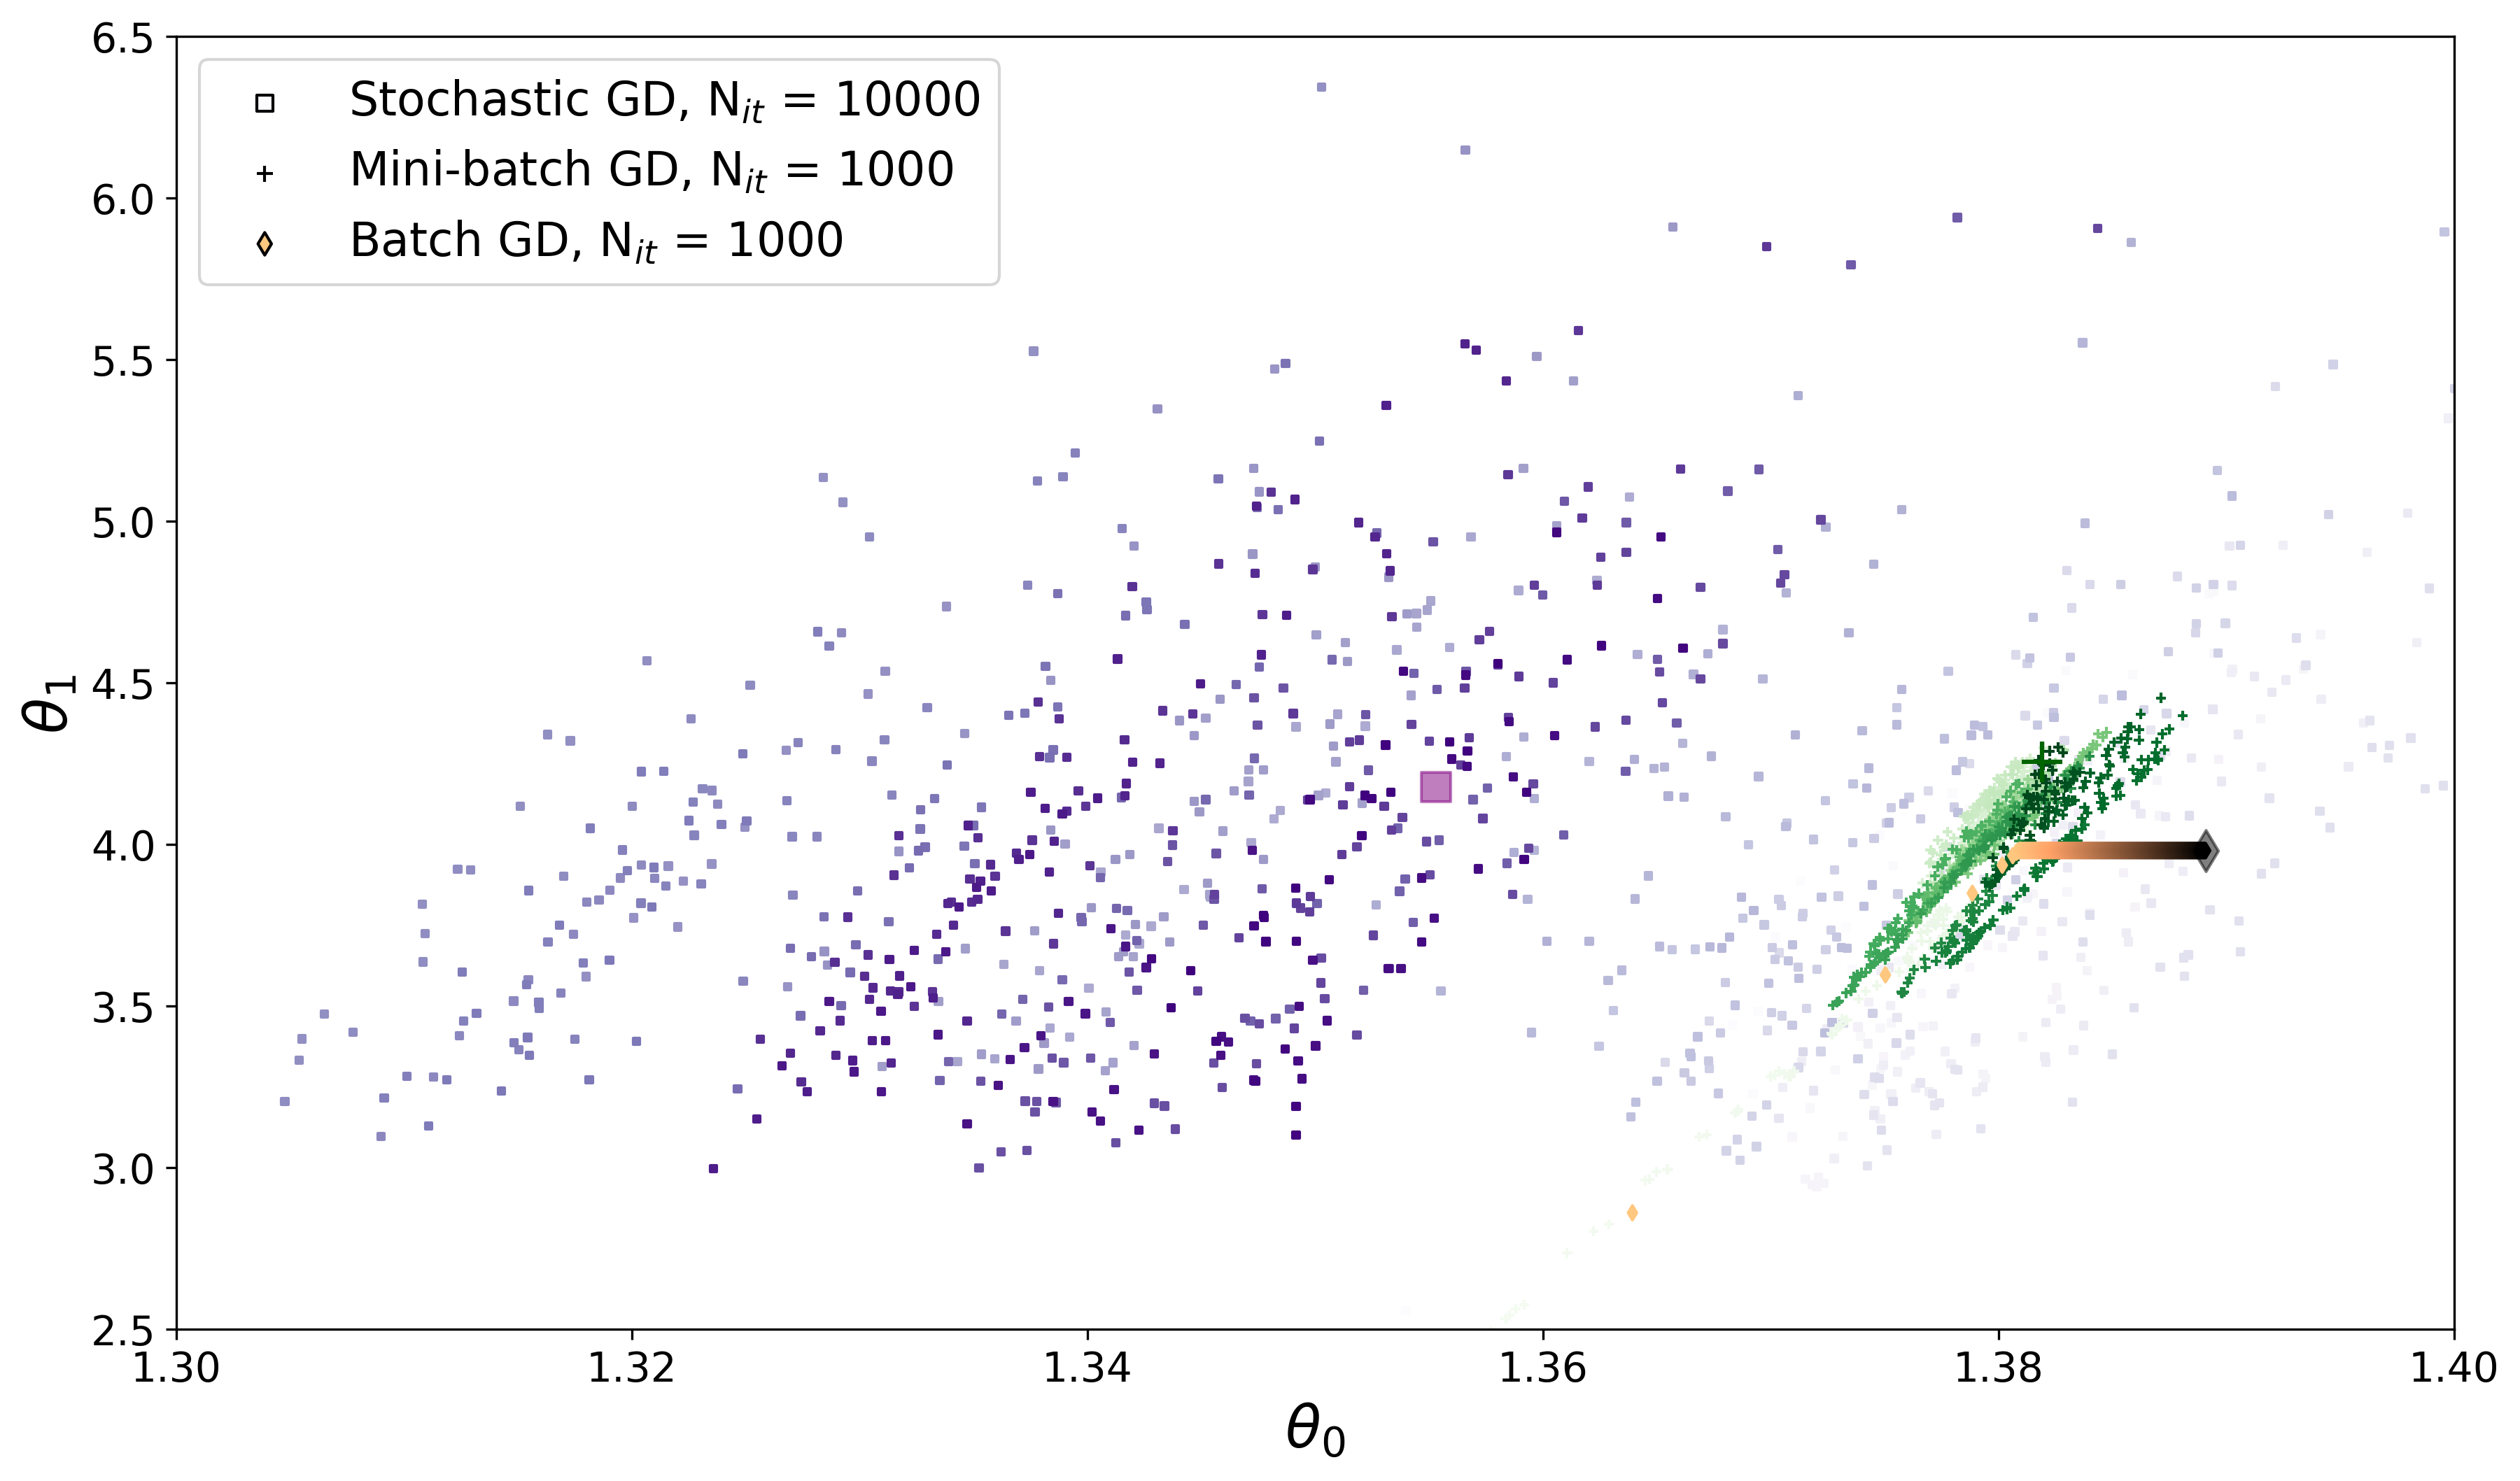

In [38]:
plt.figure(figsize=(14,8))

plt.scatter(theta_path_sgd[::10, 0].flatten(), theta_path_sgd[::10, 1].flatten(), marker = 's', s = 5, \
         label="Stochastic GD, N$_{it}$ = 10000", c = np.arange(1000), cmap=plt.cm.Purples)
plt.scatter(theta_path_mgd[:, 0].flatten(), theta_path_mgd[:, 1].flatten(), marker = "+", s = 12, linewidth=1, \
            label="Mini-batch GD, N$_{it}$ = 1000", c = np.arange(1000), cmap=plt.cm.Greens)
plt.scatter(theta_path_bgd[:, 0].flatten(), theta_path_bgd[:, 1].flatten(), marker = "d", s = 12, linewidth=1, \
            label="Batch GD, N$_{it}$ = 1000", c = np.arange(1000,0,-1), cmap=plt.cm.copper)

plt.scatter(theta_sgd[0],theta_sgd[1], marker = "s", s = 100, color = 'Purple', alpha = 0.5)
plt.scatter(theta_mgd[0],theta_mgd[1], marker = "+", s = 200, color = 'DarkGreen', alpha = 1)
plt.scatter(theta_bgd[0],theta_bgd[1], marker = "d", s = 100, color = 'k', alpha = 0.5)

legend = plt.legend(loc="upper left", fontsize=16)


for i in range(3):

    legend.legend_handles[i].set_color('k')
    legend.legend_handles[i]._sizes = [30]

plt.xlabel(r"$\theta_0$", fontsize=20)
plt.ylabel(r"$\theta_1$   ", fontsize=20)

plt.axis([1.3, 1.4, 2.5, 6.5])

#plt.savefig('AllThePaths.png', dpi = 300)
plt.show()


### Preguntas

1. Identifica en el código de mini batch GD dónde ocurre cada paso:

   - cálculo de las predicciones: xi.dot(theta)
   - cálculo del error o residuo: xi.dot(theta) -yi
   - cálculo del gradiente: gradients = 2/minibatch_size * xi.T.dot(xi.dot(theta) - yi)
   - actualización de los parámetros: theta = theta - eta *gradients

2. ¿Qué representan los parámetros $\theta_0$ y $\theta_1$ en este modelo?


   $\theta_0$ representa el intercepto, el valor predicho con x=0
   $\theta_1$ representa la pendiente, la razon de cambio de x con respecto a y

3. Compara los parámetros encontrados por Gradient Descent con los obtenidos mediante `LinearRegression`. ¿Son iguales o parecidos? ¿Por qué no necesariamente coinciden exactamente?\
Son parecidos pero no iguales, no coinciden perfectamente por que la regresión normal usa una ecuación para llegar al minimo a diferencia del Gradiente Decent itera partiendo desde un punto aleatorio pero puede no llegar a converger despues de 1000 iteraciones.

4. Cambia el learning rate $\eta$. Prueba al menos tres valores: uno pequeño, uno razonable y uno demasiado grande. ¿Qué ocurre en cada caso?\
En tanto en el caso de eta= 0.005 como en el de eta=0.5 este resulto demasiado grande por lo que el theta resulto en NaN en ambos casos.

5. Explica con tus palabras por qué la actualización tiene un signo menos: $\theta \leftarrow \theta - \eta \nabla L$ \
El gradiente de L apunta hacia donde el cremiento es mayor pero nosotros queremos minimizarlo, por lo tanto el signo representa el cambio de sentido de ir al punto maximo a ir hacia el punto minimo.
6. En la solución analítica derivamos e igualamos a cero. En Gradient Descent no resolvemos directamente la ecuación.  ¿Qué hacemos en cambio?\
Se aproxima la solución calculando el gradiente en un $\theta$ aleatorio luego se avanza un paso eta en dirección contraria al gradiente y se repite hasta que los cambios en $\theta$ son despreciables o se acaban los pasos designados.

7. Compara Batch Gradient Descent, Stochastic Gradient Descent y Mini-batch Gradient Descent.

   - ¿Cuál usa todos los datos en cada actualización?
   - ¿Cuál actualiza los parámetros con más ruido?
   - ¿Cuál parece converger de forma más suave?


| Caracteristica           | Batch Gradient Decent | Stochastic Gradient Descent |Mini-batch Gradient Descent | 
| ----------------- | -------: | ---------------: | ------------: | 
| Datos por actualización  | Todos        | uno              | diez             |
| Ruido | Minimo        | Máximo                 | Intermedio              | 
| Convergencia | Suave        | Brusca                 | Intermedio              | 
| Ruido | 1000       | 1000 (no son suficientes)                | 1000              | 